In [1]:
#Import Library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Tema Visualisasi
sns.set_theme(style="whitegrid")

In [ ]:
#Load Dataset
df = pd.read_csv('../data/dataset_balanced.csv', sep=None, engine='python')

#Perbaikan Data Angka
df['Curricular units 1st sem (grade)'] = pd.to_numeric(df['Curricular units 1st sem (grade)'].astype(str).str.replace('.', '', regex=False), errors='coerce')
df['Curricular units 2nd sem (grade)'] = pd.to_numeric(df['Curricular units 2nd sem (grade)'].astype(str).str.replace('.', '', regex=False), errors='coerce')

if df['Curricular units 1st sem (grade)'].max() > 20:
    df['Curricular units 1st sem (grade)'] = df['Curricular units 1st sem (grade)'] / 100000000000000
if df['Curricular units 2nd sem (grade)'].max() > 20:
    df['Curricular units 2nd sem (grade)'] = df['Curricular units 2nd sem (grade)'] / 100000000000000

In [4]:
#Menghitung Statistik di Awal
status_counts = df['Target'].value_counts()
beasiswa_counts = df['Scholarship holder'].value_counts()
penerima = beasiswa_counts.get(1, beasiswa_counts.get('1', 0))
bukan_penerima = beasiswa_counts.get(0, beasiswa_counts.get('0', 0))

#Analisis Variabel Akademik


/tmp/ipykernel_7313/3433764876.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Dropout', 'Enrolled', 'Graduate'])
/tmp/ipykernel_7313/3433764876.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Dropout', 'Enrolled', 'Graduate'])


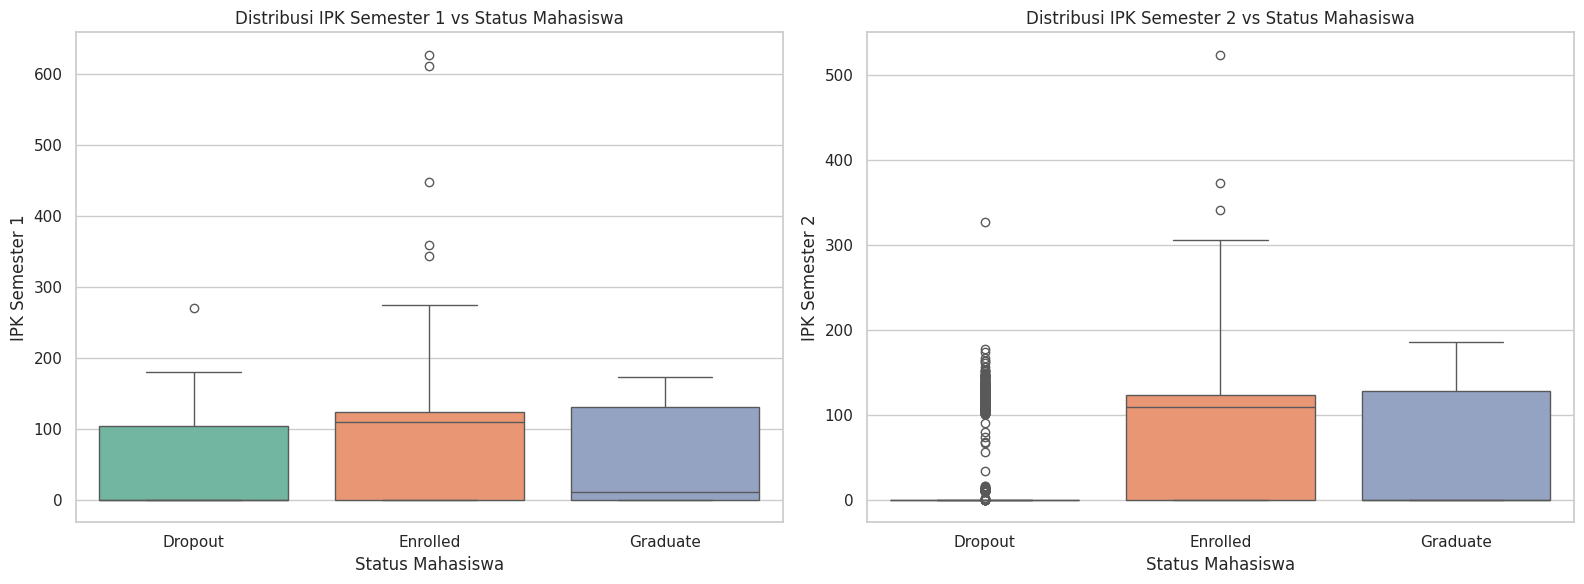


📋 KETERANGAN DATA GRAFIK AKADEMIK:
  - Jumlah Mahasiswa Lulus (Graduate)       : 0 mahasiswa
  - Jumlah Mahasiswa Putus Kuliah (Dropout) : 0 mahasiswa
  - Jumlah Mahasiswa Aktif (Enrolled)       : 0 mahasiswa
  - Total Keseluruhan Sampel Mahasiswa      : 6627 mahasiswa




In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot IPK Semester 1
sns.boxplot(data=df, x='Target', y='Curricular units 1st sem (grade)', hue='Target', ax=axes[0], palette='Set2', legend=False)
axes[0].set_title('Distribusi IPK Semester 1 vs Status Mahasiswa')
axes[0].set_xlabel('Status Mahasiswa')
axes[0].set_ylabel('IPK Semester 1')
axes[0].set_xticklabels(['Dropout', 'Enrolled', 'Graduate'])

# Boxplot IPK Semester 2
sns.boxplot(data=df, x='Target', y='Curricular units 2nd sem (grade)', hue='Target', ax=axes[1], palette='Set2', legend=False)
axes[1].set_title('Distribusi IPK Semester 2 vs Status Mahasiswa')
axes[1].set_xlabel('Status Mahasiswa')
axes[1].set_ylabel('IPK Semester 2')
axes[1].set_xticklabels(['Dropout', 'Enrolled', 'Graduate'])

plt.tight_layout()
plt.show()

print("\n📋 KETERANGAN DATA GRAFIK AKADEMIK:")
print(f"  - Jumlah Mahasiswa Lulus (Graduate)       : {status_counts.get('Graduate', 0)} mahasiswa")
print(f"  - Jumlah Mahasiswa Putus Kuliah (Dropout) : {status_counts.get('Dropout', 0)} mahasiswa")
print(f"  - Jumlah Mahasiswa Aktif (Enrolled)       : {status_counts.get('Enrolled', 0)} mahasiswa")
print(f"  - Total Keseluruhan Sampel Mahasiswa      : {len(df)} mahasiswa")
print("\n" + "="*80 + "\n")

#Analisis Variabel Sosial Ekonomi

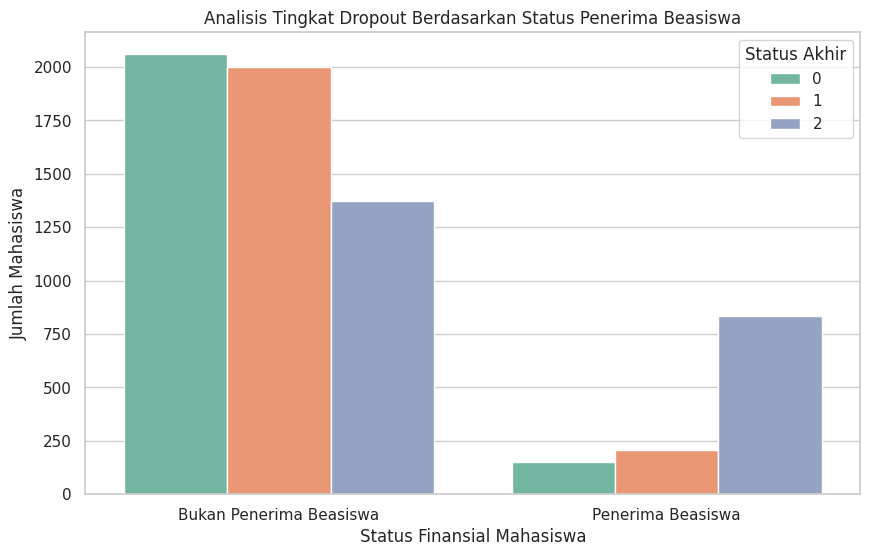


📋 KETERANGAN DATA GRAFIK SOSIAL-EKONOMI:
  - Jumlah Mahasiswa Penerima Beasiswa      : 1192 mahasiswa
  - Jumlah Mahasiswa Bukan Penerima Beasiswa: 5435 mahasiswa
  - Total Keseluruhan Sampel Mahasiswa      : 6627 mahasiswa




In [6]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x='Scholarship holder', hue='Target', palette='Set2')

plt.title('Analisis Tingkat Dropout Berdasarkan Status Penerima Beasiswa')
plt.ylabel('Jumlah Mahasiswa')
plt.xticks(ticks=[0, 1], labels=['Bukan Penerima Beasiswa', 'Penerima Beasiswa'])
plt.xlabel('Status Finansial Mahasiswa')

plt.legend(title='Status Akhir')
plt.show()

penerima = beasiswa_counts.get(1, beasiswa_counts.get('1', 0))
bukan_penerima = beasiswa_counts.get(0, beasiswa_counts.get('0', 0))
print("\n📋 KETERANGAN DATA GRAFIK SOSIAL-EKONOMI:")
print(f"  - Jumlah Mahasiswa Penerima Beasiswa      : {penerima} mahasiswa")
print(f"  - Jumlah Mahasiswa Bukan Penerima Beasiswa: {bukan_penerima} mahasiswa")
print(f"  - Total Keseluruhan Sampel Mahasiswa      : {len(df)} mahasiswa")
print("\n" + "="*80 + "\n")

#Analisis Hubungan dan Korelasi Variabel


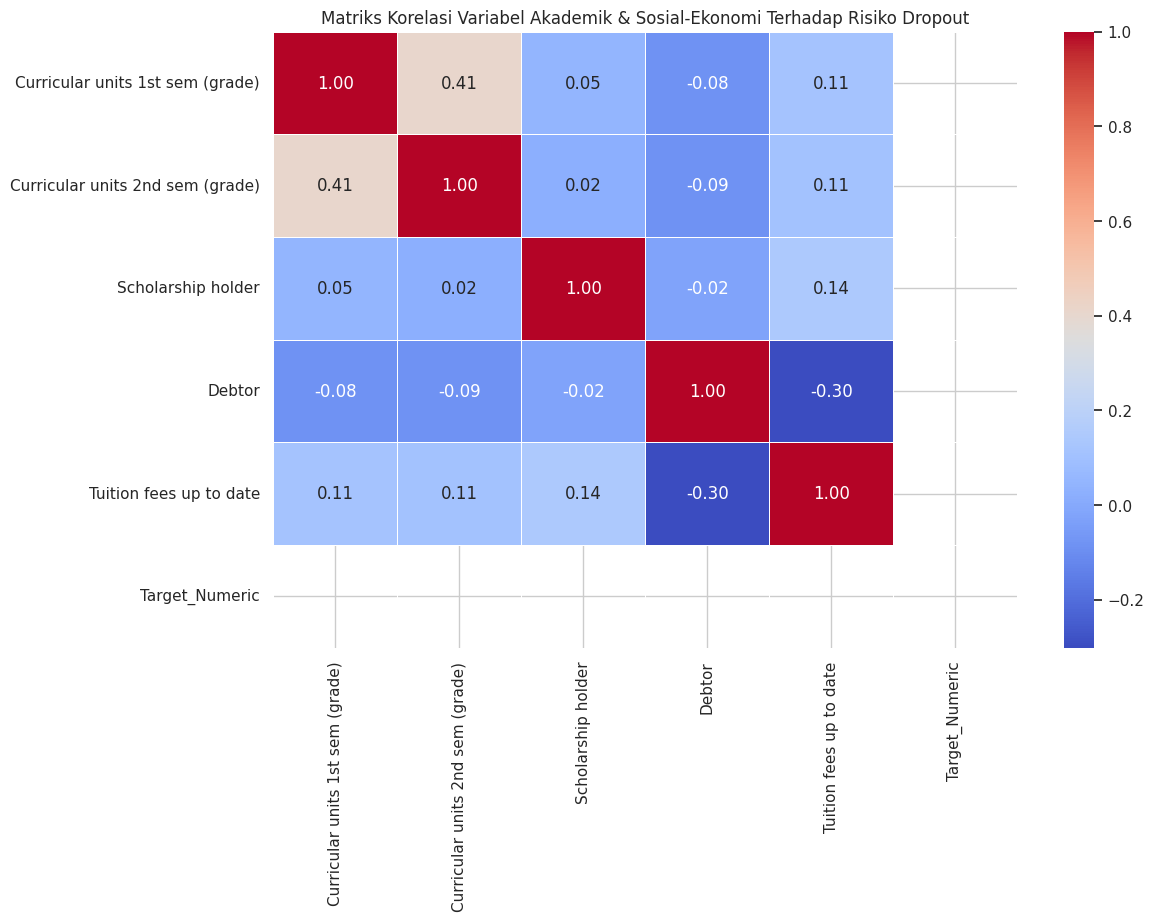

In [7]:
plt.figure(figsize=(12, 8))

kolom_kunci = [
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Scholarship holder',
    'Debtor',
    'Tuition fees up to date'
]

df_numeric = df[kolom_kunci].copy()
df_numeric['Target_Numeric'] = df['Target'].map({'Dropout': 1, 'Graduate': 0, 'Enrolled': 0.5})

# Menghitung korelasi dan menampilkan heatmap
corr_matrix = df_numeric.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriks Korelasi Variabel Akademik & Sosial-Ekonomi Terhadap Risiko Dropout')
plt.show()